# Discrete Wavelet Transform for R-Peak Detection

In this notebook, we implement and compare two different discrete wavelet approaches using the `sym4` wavelet:
1. **Stationary Wavelet Transform (SWT)**: Un-decimated transform, preserving perfect time resolution at all levels.
2. **Discrete Wavelet Transform (DWT + MRA)**: Standard decimated DWT, but using Multi-Resolution Analysis (inverse DWT) to reconstruct the signal from the QRS-specific frequency bands.

Both methods extract the Detail coefficients D3 and D4 (corresponding to ~11 Hz - 45 Hz), square them for energy, smooth the signal, and detect peaks using adaptive thresholding.



In [1]:
import os
import glob
import wfdb
import pywt
import numpy as np
import scipy.signal as signal
import pandas as pd
import matplotlib.pyplot as plt
import time

plt.rcParams['figure.figsize'] = (12, 4)



## 1. Helper Functions


In [2]:
def get_annotated_peaks(record_path):
    ann = wfdb.rdann(record_path, 'atr')
    beat_types = ['N', 'L', 'R', 'B', 'A', 'a', 'J', 'S', 'V', 'r', 'F', 'e', 'j', 'n', 'E', '/', 'f', 'Q', '?']
    beats = [ann.sample[i] for i in range(len(ann.symbol)) if ann.symbol[i] in beat_types]
    return np.array(beats)

def evaluate_peaks(detected_peaks, annotated_peaks, fs, tolerance_ms=150):
    tolerance = int(tolerance_ms / 1000.0 * fs)
    tp = 0; fn = 0
    detected_matched = set()
    for ann in annotated_peaks:
        close_peaks = [p for p in detected_peaks if abs(p - ann) <= tolerance]
        if close_peaks:
            closest = min(close_peaks, key=lambda x: abs(x - ann))
            if closest not in detected_matched:
                tp += 1
                detected_matched.add(closest)
            else:
                fn += 1
        else:
            fn += 1
    fp = len(detected_peaks) - len(detected_matched)
    return tp, fp, fn

def apply_adaptive_threshold(energy, ecg, fs):
    """Applies moving average and adaptive thresholding to find R-peaks."""
    window_size = int(0.10 * fs)
    smoothed = np.convolve(energy, np.ones(window_size) / window_size, mode='same')
    
    min_distance = int(0.20 * fs) 
    candidate_peaks, _ = signal.find_peaks(smoothed, distance=min_distance)
    
    if len(smoothed) > 2*fs:
        spk = np.max(smoothed[:2*fs])
        npk = np.mean(smoothed[:2*fs])
    else:
        spk = np.max(smoothed)
        npk = np.mean(smoothed)
        
    threshold1 = npk + 0.25 * (spk - npk)
    r_peaks = []
    
    for peak in candidate_peaks:
        peak_val = smoothed[peak]
        if peak_val > threshold1:
            spk = 0.125 * peak_val + 0.875 * spk
            r_peaks.append(peak)
        else:
            npk = 0.125 * peak_val + 0.875 * npk
        threshold1 = npk + 0.25 * (spk - npk)
        
    search_radius = int(0.10 * fs)
    refined_peaks = []
    for p in r_peaks:
        start = max(0, p - search_radius)
        end = min(len(ecg), p + search_radius)
        if start < end:
            local_max = np.argmax(np.abs(ecg[start:end]))
            refined_peaks.append(start + local_max)
    return np.array(sorted(set(refined_peaks)))



## 2. Stationary Wavelet Transform (SWT) Pipeline


In [3]:
def detect_r_peaks_swt(ecg, fs):
    """
    Uses Stationary Wavelet Transform (SWT). Does not decimate the signal.
    """
    level = 4
    # SWT requires input length to be a multiple of 2**level
    pad_len = (2**level) - (len(ecg) % (2**level))
    if pad_len != (2**level):
        ecg_padded = np.pad(ecg, (0, pad_len), 'constant')
    else:
        ecg_padded = ecg
        
    coeffs = pywt.swt(ecg_padded, 'sym4', level=level)
    
    # coeffs format: [(cA4, cD4), (cA3, cD3), (cA2, cD2), (cA1, cD1)]
    cD4 = coeffs[0][1]
    cD3 = coeffs[1][1]
    
    # Combine Energy from D3 (22.5-45 Hz) and D4 (11.25-22.5 Hz)
    energy = cD3**2 + cD4**2
    
    if pad_len != (2**level):
        energy = energy[:-pad_len]
        
    return apply_adaptive_threshold(energy, ecg, fs)



## 3. Discrete Wavelet Transform (DWT) Pipeline


In [4]:
def detect_r_peaks_dwt(ecg, fs):
    """
    Uses decimated DWT and Multi-Resolution Analysis (inverse DWT) to isolate QRS frequencies.
    """
    level = 4
    # wavedec returns [cA4, cD4, cD3, cD2, cD1]
    coeffs = pywt.wavedec(ecg, 'sym4', level=level)
    
    # Set approximation and unwanted details to zero
    coeffs[0] = np.zeros_like(coeffs[0]) # cA4
    coeffs[3] = np.zeros_like(coeffs[3]) # cD2
    coeffs[4] = np.zeros_like(coeffs[4]) # cD1
    
    # Reconstruct the signal using only D3 and D4
    reconstructed = pywt.waverec(coeffs, 'sym4')
    
    # Trim if reconstruction is off by 1 due to padding logic
    if len(reconstructed) > len(ecg):
        reconstructed = reconstructed[:len(ecg)]
        
    energy = reconstructed**2
    
    return apply_adaptive_threshold(energy, ecg, fs)



## 4. Visual Comparison


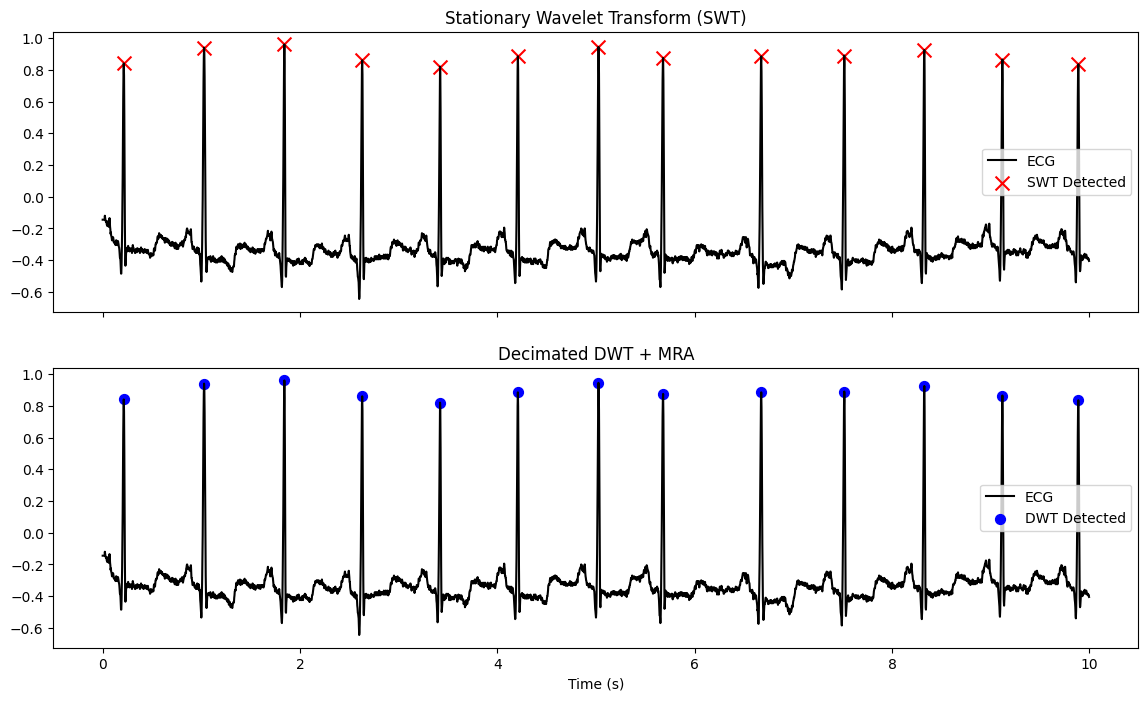

In [5]:
record_path = '100'
record = wfdb.rdsamp(record_path, sampto=3600)
ecg = record[0][:, 0]
fs = record[1]['fs']

peaks_swt = detect_r_peaks_swt(ecg, fs)
peaks_dwt = detect_r_peaks_dwt(ecg, fs)

t = np.arange(len(ecg)) / fs

fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axs[0].plot(t, ecg, color='black', label='ECG')
axs[0].scatter(t[peaks_swt], ecg[peaks_swt], color='red', marker='x', s=100, label='SWT Detected')
axs[0].set_title("Stationary Wavelet Transform (SWT)")
axs[0].legend()

axs[1].plot(t, ecg, color='black', label='ECG')
axs[1].scatter(t[peaks_dwt], ecg[peaks_dwt], color='blue', marker='o', s=50, label='DWT Detected')
axs[1].set_title("Decimated DWT + MRA")
axs[1].legend()

plt.xlabel("Time (s)")
plt.show()



## 5. Full Dataset Evaluation & Comparison
We will now loop through all MIT-BIH records and evaluate BOTH methods side-by-side to compare accuracy and computational time.



In [6]:
records = [os.path.basename(f).split('.')[0] for f in glob.glob('*.dat')]
records.sort()

results_swt = []
results_dwt = []

print(f"Starting evaluation of SWT and DWT on {len(records)} records...")

for rec in records:
    try:
        record_path = rec
        record = wfdb.rdsamp(record_path)
        ecg = record[0][:, 0]
        fs = record[1]['fs']
        ann_peaks = get_annotated_peaks(record_path)
        
        # --- SWT Evaluation ---
        t0 = time.time()
        det_swt = detect_r_peaks_swt(ecg, fs)
        time_swt = time.time() - t0
        tp, fp, fn = evaluate_peaks(det_swt, ann_peaks, fs)
        results_swt.append({'Record': rec, 'Total Beats': len(ann_peaks), 'TP': tp, 'FP': fp, 'FN': fn, 'Time (s)': time_swt})
        
        # --- DWT Evaluation ---
        t0 = time.time()
        det_dwt = detect_r_peaks_dwt(ecg, fs)
        time_dwt = time.time() - t0
        tp, fp, fn = evaluate_peaks(det_dwt, ann_peaks, fs)
        results_dwt.append({'Record': rec, 'Total Beats': len(ann_peaks), 'TP': tp, 'FP': fp, 'FN': fn, 'Time (s)': time_dwt})
        
    except Exception as e:
        pass

print("Evaluation completed.")



Starting evaluation of SWT and DWT on 45 records...
Evaluation completed.


## 6. Comparison Results


In [7]:
df_swt = pd.DataFrame(results_swt)
df_dwt = pd.DataFrame(results_dwt)

def compute_metrics(df, method_name):
    df['Sensitivity (%)'] = (df['TP'] / (df['TP'] + df['FN']) * 100).fillna(0)
    df['Predictivity (%)'] = (df['TP'] / (df['TP'] + df['FP']) * 100).fillna(0)
    
    total_beats = df['Total Beats'].sum()
    total_tp = df['TP'].sum()
    total_fp = df['FP'].sum()
    total_fn = df['FN'].sum()
    total_time = df['Time (s)'].sum()
    
    overall_se = total_tp / (total_tp + total_fn) * 100
    overall_pp = total_tp / (total_tp + total_fp) * 100
    overall_er = (total_fp + total_fn) / total_beats * 100
    
    print("="*50)
    print(f"OVERALL PERFORMANCE: {method_name}")
    print("="*50)
    print(f"Total Beats Evaluated : {total_beats}")
    print(f"True Positives (TP)   : {total_tp}")
    print(f"Sensitivity (Se)      : {overall_se:.2f} %")
    print(f"Positive Predictivity : {overall_pp:.2f} %")
    print(f"Total Processing Time : {total_time:.2f} seconds")
    print(f"Average Time / Record : {(total_time/len(df)):.3f} seconds")
    print("="*50)
    
compute_metrics(df_swt, "Stationary Wavelet Transform (SWT)")
compute_metrics(df_dwt, "Discrete Wavelet Transform (DWT)")

df_swt.to_csv('swt_mitbih_results.csv', index=False)
df_dwt.to_csv('dwt_mitbih_results.csv', index=False)
print("\nResults saved to 'swt_mitbih_results.csv' and 'dwt_mitbih_results.csv'")



OVERALL PERFORMANCE: Stationary Wavelet Transform (SWT)
Total Beats Evaluated : 102941
True Positives (TP)   : 101026
Sensitivity (Se)      : 98.14 %
Positive Predictivity : 99.70 %
Total Processing Time : 6.94 seconds
Average Time / Record : 0.154 seconds
OVERALL PERFORMANCE: Discrete Wavelet Transform (DWT)
Total Beats Evaluated : 102941
True Positives (TP)   : 97512
Sensitivity (Se)      : 94.73 %
Positive Predictivity : 99.65 %
Total Processing Time : 4.73 seconds
Average Time / Record : 0.105 seconds

Results saved to 'swt_mitbih_results.csv' and 'dwt_mitbih_results.csv'
